## Импорты и утилиты

In [ ]:
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
import statsmodels.api as sm

import matplotlib.pyplot as plt

import cvxpy

np.random.seed(42)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

In [49]:
data = pd.read_csv('full_data/full_data.csv', index_col='openTime')

In [50]:
data.index = pd.to_datetime(data.index)

In [51]:
ret_columns = []

for col in data.columns:
    if 'ret' in col:
        ret_columns.append(col)

In [52]:
ret = data[ret_columns]
mkt_s = ret.mean(axis=1)

In [54]:
ret.values

array([[ 0.01400614,  0.00256528,  0.01167561, ..., -0.00347013,
         0.01076923,  0.00025687],
       [ 0.03205839,  0.01553505, -0.00842171, ...,  0.00302801,
         0.00507357, -0.00924499],
       [-0.00610251, -0.00215963, -0.00408934, ..., -0.00996226,
        -0.01463907, -0.01140487],
       ...,
       [-0.01119209, -0.00751238, -0.0008507 , ..., -0.0127134 ,
        -0.00825436, -0.01915247],
       [ 0.01219619,  0.0091175 ,  0.01234568, ...,  0.02354673,
         0.01849568,  0.01383764],
       [ 0.00156033, -0.00971701, -0.01387721, ..., -0.00431344,
        -0.01361985, -0.00621777]], shape=(7551, 63))

### Optimization

In [83]:
close = []
high = []
low = []
open = []

for col in data.columns:
    if 'close' in col:
        close.append(col)

for col in data.columns:
    if 'high' in col:
        high.append(col)

for col in data.columns:
    if 'low' in col:
        low.append(col)

for col in data.columns:
    if 'open' in col:
        open.append(col)


### Веса

/var/folders/cw/8wwbv_5x6v78tqq_tqg5_81c0000gn/T/ipykernel_33492/3298603966.py:3: RuntimeWarning: divide by zero encountered in divide
  w_values = (data[high].shift(1).values - data[low].shift(1).values) /data[high].shift(10).values
/var/folders/cw/8wwbv_5x6v78tqq_tqg5_81c0000gn/T/ipykernel_33492/3298603966.py:3: RuntimeWarning: invalid value encountered in divide
  w_values = (data[high].shift(1).values - data[low].shift(1).values) /data[high].shift(10).values
/Users/vladii_l/anaconda3/lib/python3.11/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


<Axes: xlabel='openTime'>

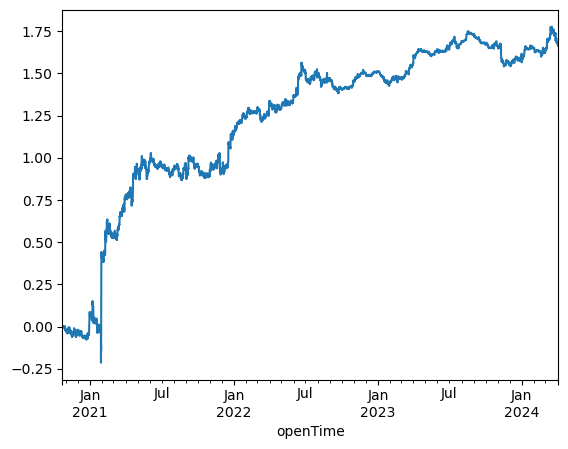

In [ ]:

w_values = (data[high].shift(1).values - data[low].shift(1).values) /data[high].shift(10).values
w = pd.DataFrame(w_values, index=data.index, columns=data[low].columns)
w = w.sub(w.mean(axis=1), axis=0)
w = w.div(w.abs().sum(axis=1), axis=0)

w = w.sub(w.mean(axis=1), axis=0)
w = w.div(w.abs().sum(axis=1), axis=0)

(w* ret.values).sum(axis=1).cumsum().plot()

### Метрики

In [434]:
pnl = (w * ret.values).sum(axis=1)

pnl_sum = pnl.sum()
vol = pnl.std()
sharpe = (pnl.mean() / vol) * np.sqrt(len(pnl) // 4)
max_dd = (
    (
        pnl.cumsum().cummax() -
        pnl.cumsum()
    ) / 
    (1 + pnl.cumsum().cummax())
).max()
tvr = (w.diff().abs()).sum(axis=1).resample('1D').sum().mean()
pm = pnl_sum / tvr

res = {
    'pnl_sum': pnl_sum,
    'volatility': vol,
    'sharpe': sharpe,
    'max_dd': max_dd,
    'tvr': tvr,
    'profit_margin': pm
}

res = pd.DataFrame(res, index=['no_beta_neutralize'])
res

,pnl_sum,volatility,sharpe,max_dd,tvr,profit_margin
no_beta_neutralize,1.66319,0.007857,1.21771,0.317389,4.581022,0.363061


In [467]:
window = 42
n_components = 5

factor_loadings = [] 
pca_weights_history = [] 

for t in range(window, len(ret)):
    hist_ret = ret.iloc[t-window:t]
    hist_ret_std = (hist_ret - hist_ret.mean()) / hist_ret.std()
    pca = PCA(n_components=n_components)
    pca.fit(hist_ret_std)
    loadings = pca.components_  
    factor_loadings.append(loadings)
    w_alpha = w.iloc[t].values

In [468]:
beta_neutral_weights = []

for t in range(window, len(ret)):
    w_alpha = w.iloc[t].values
    loadings = factor_loadings[t - window]
    
    A = np.ones((1, len(w_alpha)))
    A = np.vstack([A, loadings])
    b = np.zeros(A.shape[0])
    
    try:
        At = A.T
        AAt = A @ At
        AAt_inv = np.linalg.inv(AAt + 1e-8 * np.eye(AAt.shape[0]))
        x = w_alpha - At @ AAt_inv @ (A @ w_alpha)
        
    except np.linalg.LinAlgError:
        x = w_alpha - At @ np.linalg.pinv(AAt) @ (A @ w_alpha)
    
    beta_neutral_weights.append(x)

beta_neutral_weights = pd.DataFrame(beta_neutral_weights, 
                                     index=ret.index[window:],
                                     columns=ret.columns)

      Strategy  Total Return  Volatility   Sharpe    Max DD  Turnover  Profit Margin
Original Alpha      1.681497    0.007875 1.330661 -0.312423  4.581022       0.367057
   PCA Neutral      1.615288    0.005829 1.726971 -0.181868  4.910153       0.328969


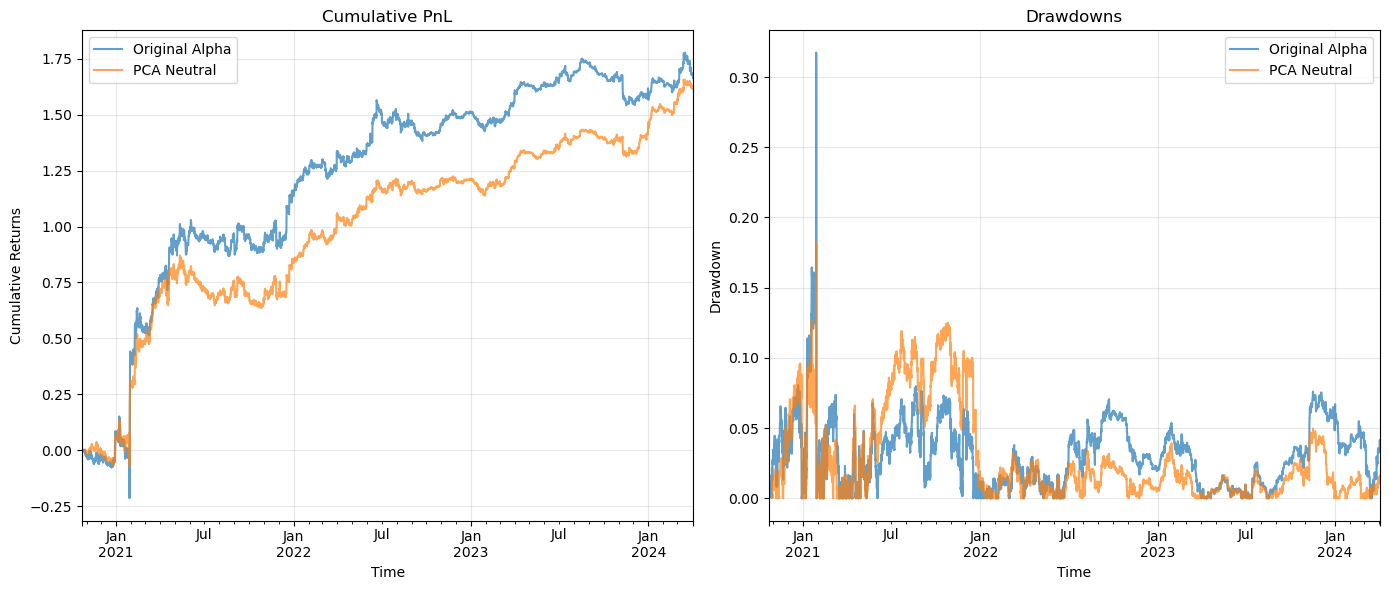

In [ ]:
pnl_pca = (beta_neutral_weights * ret.loc[beta_neutral_weights.index]).sum(axis=1)

def calculate_metrics(pnl, weights, name="Strategy"):
    """Расчет метрик для стратегии"""
    pnl = pnl.dropna()

    total_return = pnl.sum()
    volatility = pnl.std()
    sharpe = (pnl.mean() / volatility) * np.sqrt(365*6)

    cumulative = pnl.cumsum()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / (1 + running_max)
    max_dd = drawdown.min()
    tvr = weights.diff().abs().sum(axis=1).resample('1D').sum().mean()
    profit_margin = total_return / tvr if tvr != 0 else 0
    
    return {
        'Strategy': name,
        'Total Return': total_return,
        'Volatility': volatility,
        'Sharpe': sharpe,
        'Max DD': max_dd,
        'Turnover': tvr,
        'Profit Margin': profit_margin
    }

metrics_original = calculate_metrics(
    (w * ret.values).sum(axis=1).loc[beta_neutral_weights.index], 
    w, 
    "Original Alpha"
)

metrics_pca = calculate_metrics(
    pnl_pca,
    beta_neutral_weights,
    "PCA Neutral"
)

metrics_df = pd.DataFrame([metrics_original, metrics_pca])
print(metrics_df.to_string(index=False))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
(w * ret.values).sum(axis=1).cumsum().plot(label='Original Alpha', alpha=0.7)
pnl_pca.cumsum().plot(label='PCA Neutral', alpha=0.7)
plt.title('Cumulative PnL')
plt.xlabel('Time')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
cum_orig = (w * ret.values).sum(axis=1).cumsum()
dd_orig = (cum_orig.cummax() - cum_orig) / (1 + cum_orig.cummax())
dd_orig.plot(label='Original Alpha', alpha=0.7)

cum_pca = pnl_pca.cumsum()
dd_pca = (cum_pca.cummax() - cum_pca) / (1 + cum_pca.cummax())
dd_pca.plot(label='PCA Neutral', alpha=0.7)

plt.title('Drawdowns')
plt.xlabel('Time')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Выводы
Применение нейтрализации на основе PCA при правильно подобранных параметрах "Сглаживает" кривую доходности, что приводит к уменьшению волатильности и увеличению коэф. Шарпа

In [435]:
X = np.column_stack([np.ones(len(mkt_s)), mkt_s.values])

T, N = ret.shape

In [436]:
betas = np.full((T, N), np.nan, dtype=float)

In [470]:
N = 42
for t in range(N, T + 1):
    sl = slice(t - N, t)
    y_win = ret.iloc[sl].values
    X_win = X[sl]

    coef, *_ = np.linalg.lstsq(X_win, y_win, rcond=None)
    betas[t - 1, :] = coef[1, :]

betas_hat = pd.DataFrame(betas)
betas_hat.columns = ret.columns
betas_hat.index = ret.index
betas_hat

,AAVEUSDT_ret,ADAUSDT_ret,ALGOUSDT_ret,ATOMUSDT_ret,AVAXUSDT_ret,BALUSDT_ret,BANDUSDT_ret,BATUSDT_ret,BCHUSDT_ret,BLZUSDT_ret,...,UNIUSDT_ret,VETUSDT_ret,WAVESUSDT_ret,XLMUSDT_ret,XRPUSDT_ret,XTZUSDT_ret,YFIUSDT_ret,ZECUSDT_ret,ZILUSDT_ret,ZRXUSDT_ret
openTime,,,,,,,,,,,,,,,,,,,,,
2020-10-22 08:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-22 12:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-22 16:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-22 20:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-23 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-02 00:00:00+00:00,0.964296,0.920989,1.109926,0.729356,0.953085,0.934099,1.109586,1.038649,1.217897,0.296980,...,0.932312,1.293635,0.651302,0.891002,0.687038,1.099914,0.987312,0.947050,1.286397,0.985589
2024-04-02 04:00:00+00:00,0.976623,0.916852,1.085433,0.730250,0.961373,0.948974,1.100314,1.027497,1.234346,0.250959,...,0.929295,1.282517,0.792146,0.881056,0.706015,1.104637,0.966903,0.906487,1.269469,0.939869
2024-04-02 08:00:00+00:00,0.987717,0.907670,1.067635,0.726715,0.950766,0.957070,1.103054,1.028735,1.174158,0.315149,...,0.932986,1.261944,0.829474,0.883642,0.702131,1.102566,0.954704,0.926992,1.265014,0.956508


In [471]:
var_hat = ret.rolling(N).var()

###

In [472]:
beta_neut_w = []

for t in betas_hat.index:
    s = w.loc[t].values.astype(float)
    beta = betas_hat.loc[t].values.astype(float)
    var_diag = var_hat.loc[t].values.astype(float)

    N = s.shape[0]
    q = 1.0 / np.maximum(var_diag, 1e-12)
    A = np.column_stack([np.ones(N), beta])

    Qs = q * s
    QA = q[:, None] * A

    AtQA = A.T @ QA
    AtQA = AtQA + 1e-12 * np.eye(AtQA.shape[0])

    inv_AtQA = np.linalg.inv(AtQA)
    middle = QA @ inv_AtQA @ (A.T @ Qs)
    s = (Qs - middle) / 1.0

    beta_neut_w.append(s)

In [473]:
beta_neut_w = pd.DataFrame(beta_neut_w)
beta_neut_w = beta_neut_w.ffill()

In [474]:
beta_neut_w = beta_neut_w.div(beta_neut_w.abs().sum(axis=1), axis=0)

beta_neut_w.columns = ret.columns
beta_neut_w.index = ret.index

In [475]:
pnl = (w * ret.values).sum(axis=1)
pnl_ = pnl.copy()

pnl_sum = pnl.sum()
vol = pnl.std()
sharpe = (pnl.mean() / vol) * np.sqrt(len(pnl) // 4)
max_dd = (
    (
        pnl.cumsum().cummax() -
        pnl.cumsum()
    ) / 
    (1 + pnl.cumsum().cummax())
).max()
tvr = (w.diff().abs()).sum(axis=1).resample('1D').sum().mean()
pm = pnl_sum / tvr

res = {
    'pnl_sum': pnl_sum,
    'volatility': vol,
    'sharpe': sharpe,
    'max_dd': max_dd,
    'tvr': tvr,
    'profit_margin': pm
}

res1 = pd.DataFrame(res, index=['no_beta_neutralize'])

pnl = (beta_neut_w * ret.values).sum(axis=1)

pnl_sum = pnl.sum()
vol = pnl.std()
sharpe = (pnl.mean() / vol) * np.sqrt(len(pnl) // 4)
max_dd = (
    (
        pnl.cumsum().cummax() -
        pnl.cumsum()
    ) / 
    (1 + pnl.cumsum().cummax())
).max()
tvr = (beta_neut_w.diff().abs()).sum(axis=1).resample('1D').sum().mean()
pm = pnl_sum / tvr

res = {
    'pnl_sum': pnl_sum,
    'volatility': vol,
    'sharpe': sharpe,
    'max_dd': max_dd,
    'tvr': tvr,
    'profit_margin': pm
}

res2 = pd.DataFrame(res, index=['beta_neutralize'])

pd.concat([res1, res2])

,pnl_sum,volatility,sharpe,max_dd,tvr,profit_margin
no_beta_neutralize,1.66319,0.007857,1.217710,0.317389,4.581022,0.363061
beta_neutralize,0.83478,0.004570,1.050929,0.140254,6.268028,0.133181


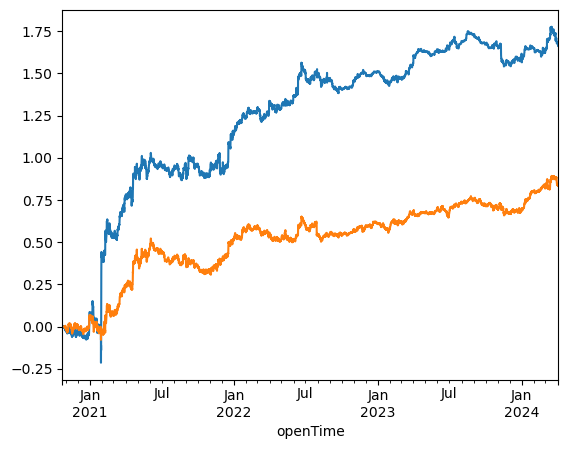

In [476]:
pnl_.cumsum().plot()
pnl.cumsum().plot()

plt.show()